# Week 1 - Day 3 Lab: Data & Matrix Manipulation
In this lab, you'll work with a realistic weather dataset. You'll use **Pandas** to explore and clean the data, and **NumPy** to perform matrix operations.

**Dataset:** `hourly_weather_10_days.csv` (10 days of hourly weather data)

## Step 1: Load the Data
- Use Pandas to load the CSV file
- Display the first few rows
- Check the number of rows and columns

In [1]:
# TODO: Load the data into a DataFrame
import pandas as pd

# Replace the file path if needed
df = pd.read_csv('hourly_weather_10_days.csv')
df.head(90)

,timestamp,temperature_C,humidity_%,wind_speed_kmph,pressure_hPa,visibility_km
0,2023-03-01 00:00:00,16.6,74.4,5.7,1012.5,9.5
1,2023-03-01 01:00:00,16.2,78.5,5.0,1012.1,10.3
2,2023-03-01 02:00:00,15.3,73.3,4.7,NaN,11.1
3,2023-03-01 03:00:00,15.8,72.4,1.3,1005.0,8.9
4,2023-03-01 04:00:00,20.9,70.6,6.8,1016.3,9.8
...,...,...,...,...,...,...
85,2023-03-04 13:00:00,25.7,56.5,12.8,1009.3,9.5
86,2023-03-04 14:00:00,24.0,59.1,14.8,1013.9,9.3
87,2023-03-04 15:00:00,19.5,62.4,14.7,1004.1,10.5
88,2023-03-04 16:00:00,23.0,57.1,12.0,1011.3,11.2


## Step 2: Basic Exploration
- Check column names and data types
- Display basic statistics using `.describe()`
- Count missing values in each column

In [2]:
# TODO: Explore the DataFrame
print(df.info())
print(df.describe())
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        240 non-null    object 
 1   temperature_C    228 non-null    float64
 2   humidity_%       224 non-null    float64
 3   wind_speed_kmph  226 non-null    float64
 4   pressure_hPa     223 non-null    float64
 5   visibility_km    228 non-null    float64
dtypes: float64(5), object(1)
memory usage: 11.4+ KB
None
       temperature_C  humidity_%  wind_speed_kmph  pressure_hPa  visibility_km
count     228.000000  224.000000       226.000000    223.000000     228.000000
mean       21.315789   66.795982        10.105310   1011.884753       9.989474
std         3.421237    8.190300         3.940668      5.187080       1.022166
min        11.500000   47.800000         1.300000    998.100000       6.800000
25%        18.700000   61.075000         6.625000   1008.900000       9.275

In [3]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        240 non-null    datetime64[ns]
 1   temperature_C    228 non-null    float64       
 2   humidity_%       224 non-null    float64       
 3   wind_speed_kmph  226 non-null    float64       
 4   pressure_hPa     223 non-null    float64       
 5   visibility_km    228 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 11.4 KB


## Step 3: Handle Missing Values
- Drop or fill missing values
- Justify your approach (e.g., fill with mean, forward fill, etc.)

In [4]:
# Percentage of missing values
(df.isnull().sum() / len(df)) * 100

timestamp          0.000000
temperature_C      5.000000
humidity_%         6.666667
wind_speed_kmph    5.833333
pressure_hPa       7.083333
visibility_km      5.000000
dtype: float64

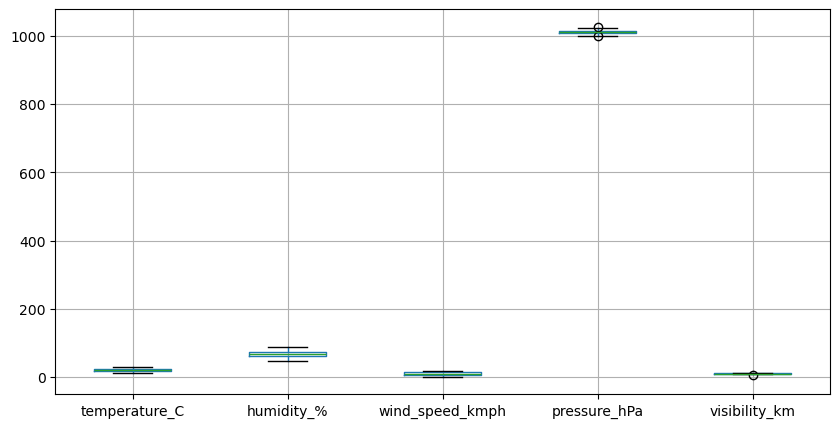

In [5]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(10,5))
plt.show()

In [6]:
# TODO: Fill missing values
# Example: df['column'] = df['column'].fillna(df['column'].mean())

# Fill in your logic here
df.ffill(inplace=True)
df.bfill(inplace=True)
df.isna().sum()

timestamp          0
temperature_C      0
humidity_%         0
wind_speed_kmph    0
pressure_hPa       0
visibility_km      0
dtype: int64

In [16]:
# Check Duplicates 

df.duplicated().sum()

0

In [17]:
# Last Checking Raw data 

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
timestamp          0
temperature_C      0
humidity_%         0
wind_speed_kmph    0
pressure_hPa       0
visibility_km      0
date               0
hour               0
dtype: int64

Duplicate Rows:
0


In [18]:
# Check datatype
print(df.dtypes)

timestamp          datetime64[ns]
temperature_C             float64
humidity_%                float64
wind_speed_kmph           float64
pressure_hPa              float64
visibility_km             float64
date                       object
hour                        int32
dtype: object


### Summary : 

In [19]:
print("========== Data Cleaning Summary ==========")
print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicate Rows : {df.duplicated().sum()}")
print("Outliers       : No Significant Outliers")
print("Missing Values : Filled using Forward Fill and Backward Fill")
print("===========================================")

========== Data Cleaning Summary ==========
Missing Values : 0
Duplicate Rows : 0
Outliers       : No Significant Outliers
Missing Values : Filled using Forward Fill and Backward Fill


## Step 4: Data Analysis
- Calculate daily average temperature
- Find max, min, mean for each metric
- Which hour of the day is the most humid on average?

### . groupby()

In [7]:
df["date"] = df["timestamp"].dt.date

daily_avg_temp = df.groupby("date")["temperature_C"].mean()

daily_avg_temp

date
2023-03-01    21.550000
2023-03-02    21.366667
2023-03-03    21.433333
2023-03-04    21.554167
2023-03-05    21.670833
2023-03-06    21.858333
2023-03-07    21.037500
2023-03-08    20.762500
2023-03-09    20.945833
2023-03-10    21.716667
Name: temperature_C, dtype: float64

### Agregation

In [8]:
df.drop(columns=["timestamp", "date"]).agg(["max", "min", "mean"])

,temperature_C,humidity_%,wind_speed_kmph,pressure_hPa,visibility_km
max,28.700000,88.10000,17.800000,1027.000000,12.600000
min,11.500000,47.80000,1.300000,998.100000,6.800000
mean,21.389583,66.79875,10.107083,1011.915833,10.002917


In [9]:
df["hour"] = df["timestamp"].dt.hour

avg_humidity_by_hour = df.groupby("hour")["humidity_%"].mean()

avg_humidity_by_hour.idxmax()


1

### Corelation()

In [20]:
correlation = df.drop(columns=["timestamp", "date", "hour"]).corr()

print(correlation)

                 temperature_C  humidity_%  wind_speed_kmph  pressure_hPa  \
temperature_C         1.000000   -0.638558         0.709599      0.004710   
humidity_%           -0.638558    1.000000        -0.721391      0.017365   
wind_speed_kmph       0.709599   -0.721391         1.000000     -0.033942   
pressure_hPa          0.004710    0.017365        -0.033942      1.000000   
visibility_km         0.043718   -0.058348         0.061378     -0.052549   

                 visibility_km  
temperature_C         0.043718  
humidity_%           -0.058348  
wind_speed_kmph       0.061378  
pressure_hPa         -0.052549  
visibility_km         1.000000  


### Visulization :

#### Line Plot

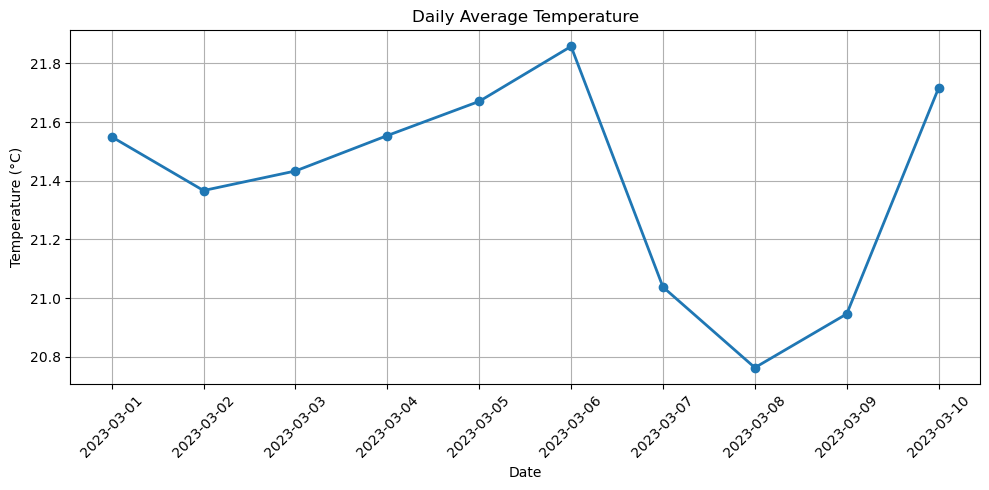

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(daily_avg_temp.index,
         daily_avg_temp.values,
         marker="o",
        linewidth = 2)

plt.title("Daily Average Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.xticks(daily_avg_temp.index)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

  
##   Observation 

  1 - The daily average temperature remained relatively stable throughout the 10-day period,
  
  2 - with only minor fluctuations. The highest average temperature was observed around March 6,
  
  3 - while the lowest occurred around March 8.

### Histogram : 

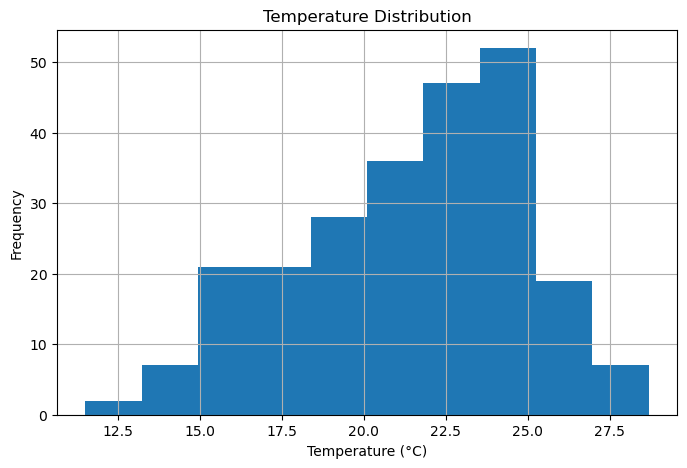

In [25]:
plt.figure(figsize=(8,5))

plt.hist(df["temperature_C"], bins=10)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

### Observation : 
1. Most temperature values are concentrated between 22°C and 25°C.

2. The distribution is approximately normal (bell-shaped), indicating that most temperature readings are around the average.

3. Very low (11–14°C) and very high (27–29°C) temperatures occur less frequently.

4. The dataset shows a stable and consistent temperature pattern with no extreme concentration at the edges.

## Box Plot

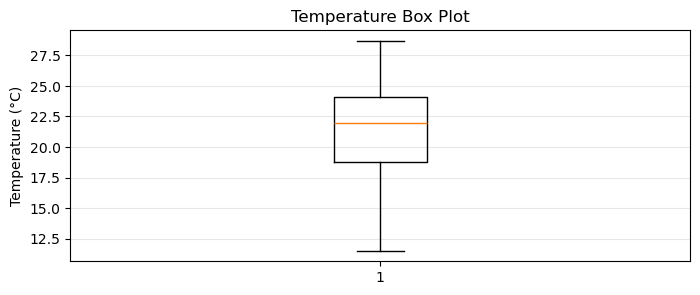

In [28]:
plt.figure(figsize=(8,3))

plt.boxplot(df["temperature_C"])

plt.title("Temperature Box Plot")
plt.ylabel("Temperature (°C)")

plt.grid(axis="y", alpha=0.3)

plt.show()

## Observation : 
1. The median temperature is approximately 22°C.

2. About 50% of the temperature values lie between 19°C and 24°C (IQR).

3. No outliers are observed, indicating a clean and consistent dataset.

4. The temperature values are reasonably spread without extreme variations.

## Correlation Heatmap

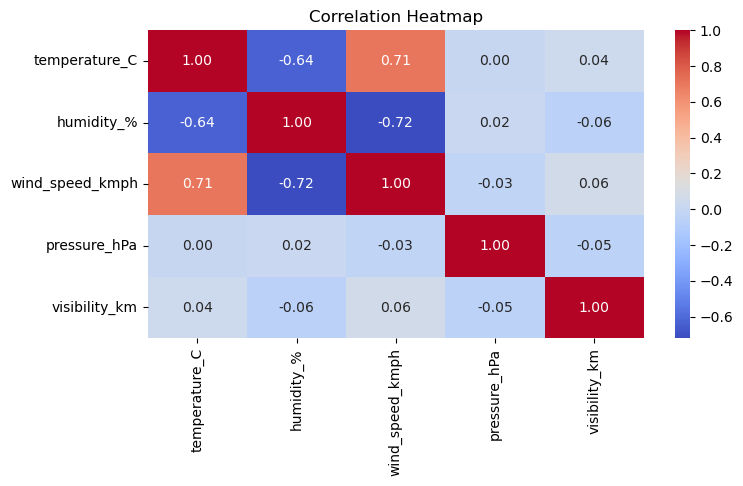

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Observation : 
1. Temperature and Wind Speed have a strong positive correlation (0.71).

2. Temperature and Humidity have a strong negative correlation (-0.64).

3. Humidity and Wind Speed also show a strong negative correlation (-0.72).

4. Pressure and Visibility have very weak correlations with other variables, indicating little or no linear relationship.

## Scater Plot

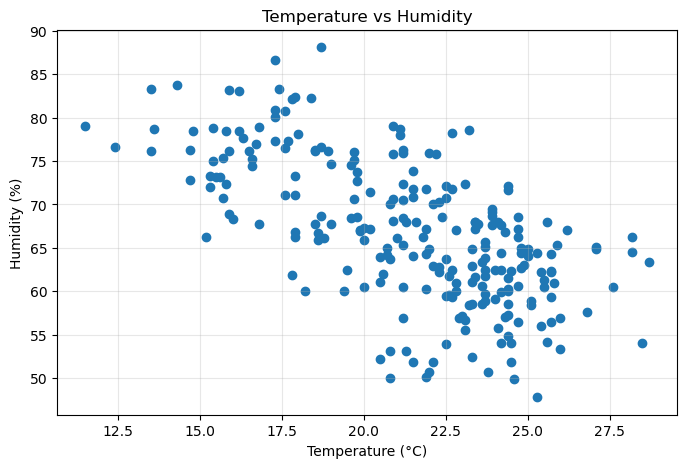

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["temperature_C"],
    df["humidity_%"]
)

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")

plt.grid(alpha=0.3)

plt.show()

## Observation 
1. The scatter plot shows a negative relationship between temperature and humidity.

2. As temperature increases, humidity generally decreases.

3. The visual trend supports the correlation coefficient (-0.64) observed in the heatmap.

## Step 5: NumPy Matrix Exercises
Convert relevant DataFrame columns into NumPy arrays and perform matrix operations.

In [10]:
# TODO: Extract temperature and wind_speed as NumPy arrays
import numpy as np

temp = df["temperature_C"].to_numpy()
wind = df["wind_speed_kmph"].to_numpy()

print(type(temp))
print(type(wind))

print(temp.shape)
print(wind.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(240,)
(240,)


### a) Reshape into matrix form
- Assume each row is a day
- Reshape temperature into a (10, 24) matrix
- Calculate daily min, max, and mean using axis-based operations

In [11]:
temp_matrix = temp.reshape((10, 24))

print(temp_matrix.shape)
print(temp_matrix)

(10, 24)
[[16.6 16.2 15.3 15.8 20.9 20.8 22.8 22.5 21.2 28.2 28.2 25.6 25.4 23.4
  27.6 23.8 22.  23.7 23.1 22.1 18.2 19.4 19.7 14.7]
 [15.9 15.7 17.6 20.  22.  21.2 22.7 21.5 23.6 28.7 20.5 25.1 22.1 24.5
  22.6 21.9 23.9 23.9 24.2 22.  19.9 18.8 16.5 18. ]
 [13.6 15.7 18.5 15.9 25.7 20.9 20.8 20.7 22.3 25.7 24.8 21.2 25.5 21.9
  22.4 24.7 24.4 24.4 23.3 24.4 22.7 20.9 18.6 15.4]
 [16.7 18.7 17.9 16.  21.5 22.1 27.1 23.7 21.9 24.2 26.8 24.4 24.4 25.7
  24.  19.5 23.  23.7 19.8 21.1 18.7 20.8 19.7 15.9]
 [19.7 12.4 18.7 18.9 21.2 21.  19.6 20.5 24.7 24.7 23.3 23.1 22.8 24.5
  24.9 24.7 24.1 22.5 24.2 23.3 22.2 23.9 16.8 18.4]
 [17.8 18.5 21.1 21.9 17.9 16.6 23.3 24.8 22.5 26.  25.4 24.3 26.2 20.8
  21.3 22.7 24.7 23.5 25.6 23.2 23.9 15.5 19.8 17.3]
 [15.8 17.6 17.9 17.9 19.8 23.4 19.9 25.7 23.1 25.9 24.4 22.5 24.8 24.5
  24.2 22.9 20.  20.7 20.5 21.9 23.2 15.4 15.3 17.6]
 [13.5 13.5 17.4 14.8 21.2 18.5 21.6 23.4 26.  22.3 22.3 24.9 23.7 23.7
  24.6 23.6 25.5 24.4 22.5 21.5 19.  17.3 15

In [12]:
# Daily minimum temprature 
daily_min = temp_matrix.min(axis=1)

# daily maximum temprture 
daily_max = temp_matrix.max(axis = 1)

# daily average temrature 
daily_mean = temp_matrix.mean(axis = 1)

print(("Minimum : "), daily_min)
print(("Maximum : "),daily_max)
print(("Mean : "),daily_mean)

Minimum :  [14.7 15.7 13.6 15.9 12.4 15.5 15.3 13.5 14.3 11.5]
Maximum :  [28.2 28.7 25.7 27.1 24.9 26.2 25.9 26.  27.1 28.5]
Mean :  [21.55       21.36666667 21.43333333 21.55416667 21.67083333 21.85833333
 21.0375     20.7625     20.94583333 21.71666667]


### b) Normalize the temperature matrix
- Subtract the mean and divide by std deviation
- Do it manually using NumPy functions

In [13]:
# TODO: Normalize temp_matrix
# Placeholder for function: def normalize(matrix):
# return ...

# Apply it to temp_matrix

def normalize(matrix):
    mean = np.mean(matrix)
    std = np.std(matrix)
    return (matrix - mean)/std


normalized_temp = normalize(temp_matrix)

print(normalized_temp)
print(normalized_temp.shape)


[[-1.38980772 -1.50587692 -1.76703261 -1.62194611 -0.14206386 -0.17108116
   0.40926482  0.32221292 -0.05501196  1.97619897  1.97619897  1.2217492
   1.1637146   0.58336862  1.80209518  0.69943781  0.17712643  0.67042051
   0.49631672  0.20614373 -0.92553093 -0.57732335 -0.49027145 -1.9411364 ]
 [-1.59292881 -1.65096341 -1.09963473 -0.40321955  0.17712643 -0.05501196
   0.38024752  0.03203993  0.64140321  2.12128547 -0.25813306  1.0766627
   0.20614373  0.90255891  0.35123022  0.14810913  0.72845511  0.72845511
   0.81550701  0.17712643 -0.43223685 -0.75142714 -1.41882502 -0.98356553]
 [-2.26032669 -1.65096341 -0.83847904 -1.59292881  1.25076649 -0.14206386
  -0.17108116 -0.20009846  0.26417833  1.25076649  0.9896108  -0.05501196
   1.1927319   0.14810913  0.29319563  0.9605935   0.87354161  0.87354161
   0.55435132  0.87354161  0.38024752 -0.14206386 -0.80946174 -1.73801531]
 [-1.36079042 -0.78044444 -1.01258283 -1.56391151  0.03203993  0.20614373
   1.65700868  0.67042051  0.14810913

### c) Apply custom mask/filter
- Create a mask for wind speed > 15 kmph
- Use it to extract high-wind readings

In [14]:
# TODO: Create boolean mask and filter wind speeds
# mask = wind > 15
# high_wind = wind[mask]
mask = wind > 15

high_wind = wind[mask]

#print("Mask:", mask)
print("High Wind Readings:", high_wind)

High Wind Readings: [17.6 16.  16.5 16.3 16.7 15.8 17.8 15.1 16.3 15.2 17.  15.9 15.6 15.8
 15.4 15.6 16.3 15.3 16.2 16.9 15.3 15.2 15.5 17.4 17.4 15.4 15.4 16.5
 17.  15.7]


## Final Challenge: Write Your Own Function
Write a function `daily_summary(matrix)` that takes a NumPy matrix of shape (10, 24) and returns a summary dictionary for each day.

In [15]:
def daily_summary(matrix):
    summary = []
    for day in matrix:
        summary.append({
            "min": round(np.min(day), 2),
            "max": round(np.max(day), 2),
            "mean": round(np.mean(day), 2)
        })
    return summary
summaries = daily_summary(temp_matrix)
print(summaries)

[{'min': 14.7, 'max': 28.2, 'mean': 21.55}, {'min': 15.7, 'max': 28.7, 'mean': 21.37}, {'min': 13.6, 'max': 25.7, 'mean': 21.43}, {'min': 15.9, 'max': 27.1, 'mean': 21.55}, {'min': 12.4, 'max': 24.9, 'mean': 21.67}, {'min': 15.5, 'max': 26.2, 'mean': 21.86}, {'min': 15.3, 'max': 25.9, 'mean': 21.04}, {'min': 13.5, 'max': 26.0, 'mean': 20.76}, {'min': 14.3, 'max': 27.1, 'mean': 20.95}, {'min': 11.5, 'max': 28.5, 'mean': 21.72}]


## Weather Dataset Analysis Summary

- Total records in the dataset: **240**
- Missing values were successfully handled using **Forward Fill** and **Backward Fill**.
- No duplicate records were found.
- No outliers were detected using the **IQR Method**.
- The average daily temperature remained relatively stable over the 10-day period.
- Most temperature values fall between **22°C and 25°C**.
- The temperature distribution is **approximately normal**.
- Temperature and Wind Speed show a **strong positive correlation (0.71)**.
- Temperature and Humidity show a **strong negative correlation (-0.64)**.
- Humidity and Wind Speed also show a **strong negative correlation (-0.72)**.
- Pressure and Visibility have **very weak correlations** with other weather variables.
- The scatter plot confirms that **humidity generally decreases as temperature increases**.

## ✅ Submit your notebook once complete.
- Add comments where necessary